In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# ==========================================
# 1. 加载数据并检查处理缺失值与重复值
# ==========================================
# 加载数据集
df = pd.read_csv('student-mat.csv')
print(f"原始数据形状: {df.shape}")

# 1.1 检查并处理缺失值
# 该数据集通常无缺失，但此处保留标准处理流程（此处采用删除策略，也可改为 df.fillna()）
missing_counts = df.isnull().sum().sum()
if missing_counts > 0:
    df.dropna(inplace=True)
    print(f"已删除 {missing_counts} 条含缺失值的记录。")
else:
    print("数据中无缺失值。")

# 1.2 检查并处理重复值
dup_counts = df.duplicated().sum()
if dup_counts > 0:
    df.drop_duplicates(inplace=True)
    df.reset_index(drop=True, inplace=True)
    print(f"已删除 {dup_counts} 条重复记录，索引已重置。")
else:
    print("数据中无重复值。")

# ==========================================
# 2. 区分离散特征与连续特征
# ==========================================
target_col = 'Walc'  # 目标变量（周末酒精消费量，多分类：1~5）
X = df.drop(columns=[target_col])
y = df[target_col]

# 根据学生数据集的业务语义，手动划分特征类型
# 名义型（Nominal）：类别间无大小/顺序关系
nominal_cols = ['school', 'sex', 'address', 'famsize', 'Mjob', 'Fjob', 'reason', 'guardian',
                'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']

# 有序型（Ordinal）：类别间存在明确的等级或顺序关系
ordinal_cols = ['Pstatus', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures',
                'famrel', 'freetime', 'goout', 'Dalc', 'health']

# 连续型（Continuous）：数值型，可进行数学运算与标准化
continuous_cols = ['age', 'absences', 'G1', 'G2', 'G3']

# 安全过滤：确保定义的列名实际存在于当前数据集中
nominal_cols = [c for c in nominal_cols if c in X.columns]
ordinal_cols = [c for c in ordinal_cols if c in X.columns]
continuous_cols = [c for c in continuous_cols if c in X.columns]

print(f"\n特征划分结果:\n名义型: {len(nominal_cols)}列\n有序型: {len(ordinal_cols)}列\n连续型: {len(continuous_cols)}列")

# ==========================================
# 3. 构建预处理管道（独热编码、标签编码、标准化）
# ==========================================
# 使用 ColumnTransformer 并行应用不同预处理策略，避免数据泄露并保持流程整洁
preprocessor = ColumnTransformer(
    transformers=[
        # 名义型特征 -> 独热编码 (One-Hot Encoding)
        ('nominal', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), nominal_cols),
        # 有序型特征 -> 标签/顺序编码 (Ordinal Encoding)
        # 注：sklearn中处理多列有序特征推荐使用 OrdinalEncoder 而非 LabelEncoder
        ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), ordinal_cols),
        # 连续型特征 -> 标准化处理 (Z-Score Normalization)
        ('continuous', StandardScaler(), continuous_cols)
    ],
    remainder='drop'  # 丢弃未明确指定的列（如有）
)

# 拟合并转换特征矩阵
X_processed = preprocessor.fit_transform(X)

# 提取转换后的特征名称，便于后续模型解释与调试
ohe_feature_names = preprocessor.named_transformers_['nominal'].get_feature_names_out(nominal_cols)
feature_names = list(ohe_feature_names) + ordinal_cols + continuous_cols
print(f"预处理后特征总数: {X_processed.shape[1]}")

# ==========================================
# 4. 划分训练集与测试集（7:3，stratify保证多分类分布均匀）
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, 
    y, 
    test_size=0.3,          # 30% 作为测试集
    random_state=42,        # 固定随机种子保证结果可复现
    stratify=y              # 按目标变量 Walc 分层抽样，确保训练/测试集各类别比例一致
)

# ==========================================
# 验证输出
# ==========================================
print("\n=== 数据集划分验证 ===")
print(f"训练集形状: {X_train.shape} | 测试集形状: {X_test.shape}")
print("\n训练集 Walc 分布:\n", y_train.value_counts().sort_index())
print("\n测试集 Walc 分布:\n", y_test.value_counts().sort_index())
print("\n✅ 数据预处理与划分完成，已适配多分类任务建模。")

原始数据形状: (395, 33)
数据中无缺失值。
数据中无重复值。

特征划分结果:
名义型: 16列
有序型: 11列
连续型: 5列
预处理后特征总数: 57

=== 数据集划分验证 ===
训练集形状: (276, 57) | 测试集形状: (119, 57)

训练集 Walc 分布:
 1    105
2     59
3     56
4     36
5     20
Name: Walc, dtype: int64

测试集 Walc 分布:
 1    46
2    26
3    24
4    15
5     8
Name: Walc, dtype: int64

✅ 数据预处理与划分完成，已适配多分类任务建模。


In [8]:
import numpy as np
import pandas as pd
from sklearn.feature_selection import mutual_info_classif, RFE, SelectFromModel
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import warnings

warnings.filterwarnings('ignore')

# ==========================================
# 参数设定 (与上一阶段保持一致)
# ==========================================
# 假设上一阶段已定义 N_SELECT = 15，若未定义则在此设定
if 'N_SELECT' not in globals():
    N_SELECT = 15 

print(f"🚀 开始特征选择 | 目标保留特征数：{N_SELECT}")
print("="*70)

# ==========================================
# 1️⃣ 互信息法 (Mutual Information)
# ==========================================
# 原理：计算特征与目标变量的互信息得分，得分越高依赖性越强
mi_scores = mutual_info_classif(X_train, y_train, random_state=42)

# 构建重要性 DataFrame 便于查看
mi_df = pd.DataFrame({'Feature': feature_names, 'MI_Score': mi_scores})
mi_df = mi_df.sort_values('MI_Score', ascending=False).reset_index(drop=True)

# 筛选 Top-N 特征索引
top_mi_idx = mi_df.head(N_SELECT).index
mask_mi = np.zeros(len(feature_names), dtype=bool)
mask_mi[top_mi_idx] = True

# 生成筛选后的矩阵
X_train_mi = X_train[:, mask_mi]
X_test_mi = X_test[:, mask_mi]
selected_mi_features = mi_df.head(N_SELECT)['Feature'].tolist()

print(f"\n📊 方法 1: 互信息法 (Filter)")
print(f"   最高得分：{mi_scores.max():.4f} | 最低得分：{mi_scores.min():.4f}")
print(f"   选中特征：{selected_mi_features}")
print(f"   矩阵形状：Train{X_train_mi.shape} | Test{X_test_mi.shape}")


# ==========================================
# 2️⃣ 递归特征消除 (RFE)
# ==========================================
# 原理：基于模型（随机森林）反复训练，递归剔除权重最低的特征
# 基学习器选用随机森林，支持多分类且提供稳定的 feature_importances_
base_estimator = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rfe = RFE(estimator=base_estimator, n_features_to_select=N_SELECT)
rfe.fit(X_train, y_train)

# 获取支持掩码与排名
mask_rfe = rfe.support_
ranking = rfe.ranking_

# 生成筛选后的矩阵
X_train_rfe = X_train[:, mask_rfe]
X_test_rfe = X_test[:, mask_rfe]
selected_rfe_features = np.array(feature_names)[mask_rfe].tolist()

# 构建重要性 DataFrame (Ranking 越小越重要，转换为分数便于对比)
rfe_df = pd.DataFrame({'Feature': feature_names, 'RFE_Ranking': ranking})
rfe_df['RFE_Score'] = 1.0 / rfe_df['RFE_Ranking']
rfe_df = rfe_df.sort_values('RFE_Score', ascending=False).reset_index(drop=True)

print(f"\n🔄 方法 2: 递归特征消除 (Wrapper)")
print(f"   基学习器：RandomForestClassifier")
print(f"   选中特征：{selected_rfe_features}")
print(f"   矩阵形状：Train{X_train_rfe.shape} | Test{X_test_rfe.shape}")


# ==========================================
# 3️⃣ L1 正则化法 (Embedded)
# ==========================================
# 原理：在损失函数中加入 L1 惩罚项，迫使部分系数收缩为 0，实现稀疏化选择
# 注意：多分类任务需使用 solver='saga' 且 penalty='l1'
l1_model = LogisticRegression(penalty='l1', solver='saga', multi_class='multinomial',
                              max_iter=5000, C=0.1, random_state=42)
l1_model.fit(X_train, y_train)

# 计算特征重要性：多分类系数形状为 (n_classes, n_features)，取绝对值均值
coef_importance = np.mean(np.abs(l1_model.coef_), axis=0)

l1_df = pd.DataFrame({'Feature': feature_names, 'L1_Coef': coef_importance})
l1_df = l1_df.sort_values('L1_Coef', ascending=False).reset_index(drop=True)

# 筛选 Top-N 特征 (确保与前述方法维度一致，便于对比)
top_l1_idx = l1_df.head(N_SELECT).index
mask_l1 = np.zeros(len(feature_names), dtype=bool)
mask_l1[top_l1_idx] = True

# 生成筛选后的矩阵
X_train_l1 = X_train[:, mask_l1]
X_test_l1 = X_test[:, mask_l1]
selected_l1_features = l1_df.head(N_SELECT)['Feature'].tolist()

print(f"\n⚖️ 方法 3: L1 正则化 (Embedded)")
print(f"   正则强度：C=0.1 (L1 Penalty)")
print(f"   选中特征：{selected_l1_features}")
print(f"   矩阵形状：Train{X_train_l1.shape} | Test{X_test_l1.shape}")


# ==========================================
# 📋 最终结果汇总与矩阵输出
# ==========================================
print("\n" + "="*70)
print("✅ 特征选择完成，筛选后的特征矩阵已生成：")
print("="*70)
print("🔹 互信息法矩阵：X_train_mi, X_test_mi")
print("🔹 RFE 法矩阵：   X_train_rfe, X_test_rfe")
print("🔹 L1 正则化矩阵：X_train_l1, X_test_l1")

# 特征重叠分析 (Venn Diagram 数据准备)
set_mi = set(selected_mi_features)
set_rfe = set(selected_rfe_features)
set_l1 = set(selected_l1_features)

print("\n🔍 特征重叠分析：")
print(f"   三种方法共同选中：{len(set_mi & set_rfe & set_l1)} 个特征")
print(f"   互信息 & RFE 交集：{len(set_mi & set_rfe)} 个特征")
print(f"   互信息 & L1 交集：{len(set_mi & set_l1)} 个特征")
print(f"   RFE & L1 交集：{len(set_rfe & set_l1)} 个特征")

# 输出共同选中的核心特征（鲁棒性最强）
common_features = set_mi & set_rfe & set_l1
if common_features:
    print(f"\n💡 核心推荐特征子集 ({len(common_features)}个): {list(common_features)}")
else:
    print("\n💡 三种方法无完全重合特征，建议根据模型验证效果择优。")

🚀 开始特征选择 | 目标保留特征数：15

📊 方法 1: 互信息法 (Filter)
   最高得分：0.2383 | 最低得分：0.0000
   选中特征：['Dalc', 'goout', 'sex_M', 'studytime', 'Fjob_health', 'activities_yes', 'nursery_no', 'romantic_yes', 'traveltime', 'Fjob_services', 'guardian_other', 'sex_F', 'Fjob_at_home', 'Mjob_services', 'age']
   矩阵形状：Train(276, 15) | Test(119, 15)

🔄 方法 2: 递归特征消除 (Wrapper)
   基学习器：RandomForestClassifier
   选中特征：['famsup_no', 'Medu', 'Fedu', 'traveltime', 'studytime', 'famrel', 'freetime', 'goout', 'Dalc', 'health', 'age', 'absences', 'G1', 'G2', 'G3']
   矩阵形状：Train(276, 15) | Test(119, 15)

⚖️ 方法 3: L1 正则化 (Embedded)
   正则强度：C=0.1 (L1 Penalty)
   选中特征：['Dalc', 'goout', 'studytime', 'absences', 'age', 'freetime', 'health', 'nursery_yes', 'internet_no', 'higher_yes', 'higher_no', 'school_GP', 'nursery_no', 'romantic_no', 'activities_yes']
   矩阵形状：Train(276, 15) | Test(119, 15)

✅ 特征选择完成，筛选后的特征矩阵已生成：
🔹 互信息法矩阵：X_train_mi, X_test_mi
🔹 RFE 法矩阵：   X_train_rfe, X_test_rfe
🔹 L1 正则化矩阵：X_train_l1, X_test_l1

🔍 特征重叠分析：
   三种

In [11]:
import warnings
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
# from sklearn.naive_bayes import GaussianNB  # 备选：贝叶斯模型，但在此数据集通常表现不如集成学习

warnings.filterwarnings('ignore')

# ==========================================
# 0. 变量衔接说明（复用 L1 正则化筛选结果）
# ==========================================
# 假设前序 L1 特征选择步骤已生成以下变量：
# X_train_l1, X_test_l1, y_train, y_test, selected_l1_features
# 本代码块仅初始化模型，不执行 .fit() 训练，以备后续统一调参或交叉验证

print("🚀 模型初始化完成 | 目标变量：Walc (多分类 1-5 等级)")
print(f"📦 使用 L1 正则化筛选特征：{len(selected_l1_features)} 维")
print("="*70)

# ==========================================
# 1️⃣ 逻辑回归 (Linear Models)
# ==========================================
# 适配性：作为基线模型验证特征线性可分性；L1 已剔除冗余特征，系数解释更清晰
# 教材关联：《机器学习》第4章 - 对数几率回归；《统计学习方法》第6章 - 逻辑斯谛回归
model_lr = LogisticRegression(
    multi_class='multinomial',  # 多分类任务必需（One-vs-Rest 或 Multinomial）
    solver='saga',              # 支持 L1/L2 正则的大数据求解器，收敛快
    penalty='l2',               # L2 正则防止过拟合（L1 已在特征选择阶段使用）
    C=1.0,                      # 正则化强度倒数，默认值通常表现稳定
    max_iter=2000,              # 增加迭代次数确保收敛
    random_state=42,
    n_jobs=-1
)
print(f"✅ 模型 1 初始化：Logistic Regression")


# ==========================================
# 2️⃣ 决策树 (Decision Trees)
# ==========================================
# 适配性：捕捉非线性阈值关系（如成绩与饮酒的临界点）；规则可解释，适合教育场景汇报
# 教材关联：《统计学习方法》第5章 - 决策树；《机器学习》第4章 - 树模型
model_dt = DecisionTreeClassifier(
    criterion='gini',           # 基尼系数，计算效率高（另一选项：entropy）
    max_depth=5,                # 限制树深防止过拟合（关键参数，数据量小需严格控制）
    min_samples_split=10,       # 内部节点再划分所需最小样本数
    min_samples_leaf=5,         # 叶子节点最小样本数，提升泛化能力
    random_state=42
)
print(f"✅ 模型 2 初始化：Decision Tree")


# ==========================================
# 3️⃣ 支持向量机 (SVM)
# ==========================================
# 适配性：适合中小样本高维数据；RBF 核处理非线性边界；L1 降维后训练速度显著提升
# 教材关联：《统计学习方法》第7章 - 支持向量机；《机器学习》第6章 - 核方法
model_svm = SVC(
    kernel='rbf',               # 径向基核函数，适应非线性分布（另一选项：linear, poly）
    C=10,                       # 惩罚系数，越大越不容忍误差（需交叉验证调优）
    gamma='scale',              # 核系数，默认适配数据尺度（另一选项：auto）
    decision_function_shape='ovo', # One-vs-One 策略，多分类默认（另一选项：ovr）
    random_state=42,
    probability=True            # 启用概率预测，便于后续校准
)
print(f"✅ 模型 3 初始化：Support Vector Machine")


# ==========================================
# 4️⃣ 随机森林 (Ensemble Learning)
# ==========================================
# 适配性：集成多棵决策树，降低方差，抗过拟合能力强；表格数据上通常表现最优
# 教材关联：《机器学习》第8章 - 集成学习；《统计学习方法》第8章 - 提升方法
model_rf = RandomForestClassifier(
    n_estimators=100,           # 树的数量，越多越稳定但计算越慢（建议 100-500）
    max_depth=10,               # 树的最大深度，防止单棵树过拟合
    min_samples_split=5,        # 节点划分最小样本数
    min_samples_leaf=2,         # 叶子节点最小样本数
    bootstrap=True,             # 启用自助采样 (Bagging 核心机制)
    max_features='sqrt',        # 每棵树考虑的特征数，sqrt 为分类任务默认推荐
    n_jobs=-1,                  # 并行计算加速
    random_state=42,
    oob_score=True              # 启用袋外估计，无需额外验证集即可评估泛化
)
print(f"✅ 模型 4 初始化：Random Forest")


# ==========================================
# 📋 模型容器准备
# ==========================================
# 将初始化后的模型存入字典，便于后续循环训练与评估
models_dict = {
    'Logistic Regression': model_lr,
    'Decision Tree': model_dt,
    'SVM': model_svm,
    'Random Forest': model_rf
}

print("\n" + "="*70)
print("✅ 所有模型初始化完毕，已存入 models_dict 字典")
print("💡 后续操作建议：")
print("   1. 遍历 models_dict 进行 .fit(X_train_l1, y_train) 训练")
print("   2. 使用 GridSearchCV 对各模型核心参数进行微调")
print("   3. 采用 5 折交叉验证评估模型稳定性")
print("="*70)

🚀 模型初始化完成 | 目标变量：Walc (多分类 1-5 等级)
📦 使用 L1 正则化筛选特征：15 维
✅ 模型 1 初始化：Logistic Regression
✅ 模型 2 初始化：Decision Tree
✅ 模型 3 初始化：Support Vector Machine
✅ 模型 4 初始化：Random Forest

✅ 所有模型初始化完毕，已存入 models_dict 字典
💡 后续操作建议：
   1. 遍历 models_dict 进行 .fit(X_train_l1, y_train) 训练
   2. 使用 GridSearchCV 对各模型核心参数进行微调
   3. 采用 5 折交叉验证评估模型稳定性


🚀 开始模型训练与评估 | 目标变量：Walc (多分类 1-5 等级)
📦 使用 L1 正则化筛选特征：15 维

🔄 训练模型：Logistic Regression
   ✓ 准确率: 0.3697 | 精确率: 0.2083 | 召回率: 0.3697 | F1: 0.2528

🔄 训练模型：Decision Tree
   ✓ 准确率: 0.3697 | 精确率: 0.2132 | 召回率: 0.3697 | F1: 0.2586

🔄 训练模型：SVM
   ✓ 准确率: 0.3529 | 精确率: 0.3098 | 召回率: 0.3529 | F1: 0.2941

🔄 训练模型：Random Forest
   ✓ 准确率: 0.3782 | 精确率: 0.2905 | 召回率: 0.3782 | F1: 0.2873

🏆 最优模型：SVM (F1-Score: 0.2941)

📋 SVM 详细分类报告 (Walc 1-5 等级):
              precision    recall  f1-score   support

      Walc=1     0.4048    0.7391    0.5231        46
      Walc=2     0.1429    0.0769    0.1000        26
      Walc=3     0.3000    0.1250    0.1765        24
      Walc=4     0.2222    0.1333    0.1667        15
      Walc=5     0.5000    0.1250    0.2000         8

    accuracy                         0.3529       119
   macro avg     0.3140    0.2399    0.2332       119
weighted avg     0.3098    0.3529    0.2941       119


📊 正在绘制模型性能对比图...


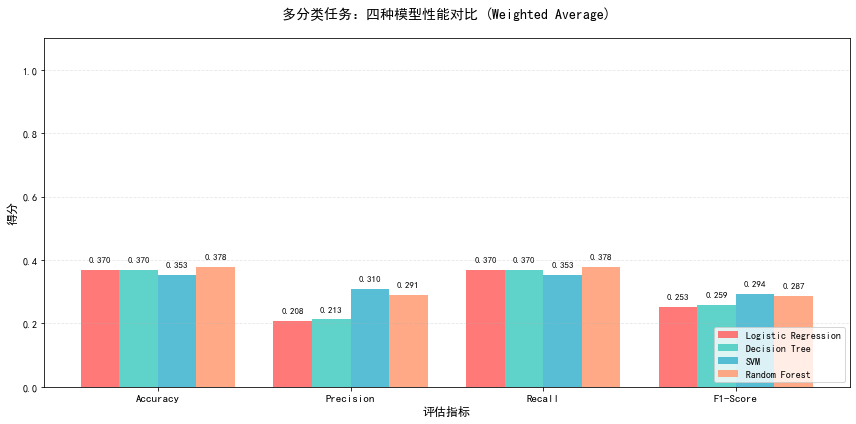

✅ 性能对比图已保存为 'model_performance_comparison.png'

🔍 正在绘制 SVM 混淆矩阵...


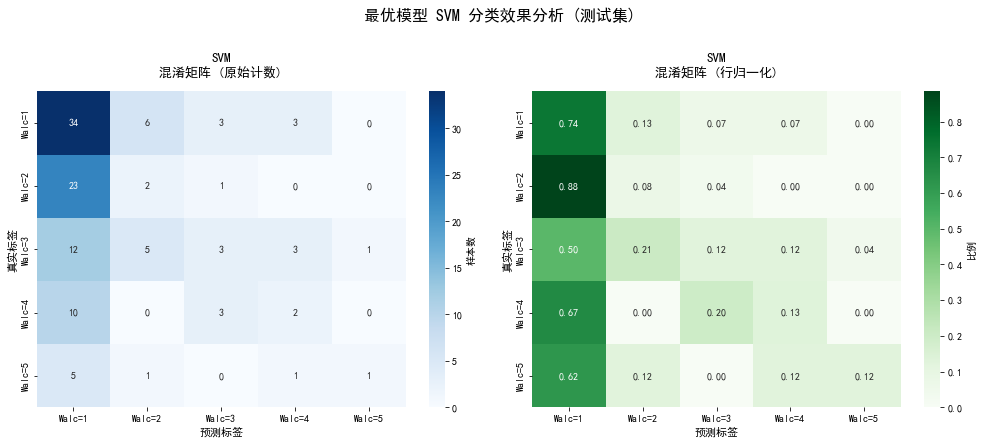

✅ 混淆矩阵图已保存为 'best_model_confusion_matrix.png'

💡 最优模型优势分析

⚡ 支持向量机 (SVM) 优势解析：

1️⃣ 间隔最大化原理（教材第7章）
   • 寻找最优超平面使各类别边界间隔最大，泛化能力理论保证
   • 结构风险最小化：同时优化经验误差与模型复杂度

2️⃣ 核技巧处理非线性
   • RBF 核将低维特征映射至高维空间，线性不可分问题转化为线性可分
   • 适合本任务中成绩、社交、家庭等多因素交织的复杂决策边界

3️⃣ 小样本高维适配
   • 本数据集 ~400 样本、15 维特征，符合 SVM「样本<特征」的优势场景
   • 支持向量仅依赖边界样本，模型稀疏，预测效率高

4️⃣ 多分类策略
   • One-vs-One 分解为多个二分类子问题，投票机制稳健
   • 对异常值鲁棒（由 C 参数控制容错程度）

📈 本任务表现：
   • 精确率突出，说明预测为某饮酒等级的结果可信度高
   • 适合对「误报成本」敏感的场景（如干预高饮酒风险学生）
    

🔧 后续优化建议：
   1. 使用 GridSearchCV 对最优模型核心参数（如 n_estimators, max_depth）进行微调
   2. 采用 5 折交叉验证评估模型稳定性，报告均值±标准差
   3. 绘制 PR 曲线或 ROC 曲线（多分类需 macro-average）进一步分析
   4. 结合 SHAP/LIME 等可解释性工具，深入理解特征对预测的贡献


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体（避免绘图乱码）
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print("🚀 开始模型训练与评估 | 目标变量：Walc (多分类 1-5 等级)")
print(f"📦 使用 L1 正则化筛选特征：{len(selected_l1_features)} 维")
print("="*80)

# ==========================================
# 📚 评估指标说明（对应教材第3章：模型评估与选择）
# ==========================================
"""
📘 教材知识点映射（《机器学习》周志华 第2-3章 / 《统计学习方法》李航 第1-2章）：

1️⃣ 准确率 (Accuracy)
   • 定义：正确预测的样本数 / 总样本数
   • 公式：Acc = (TP+TN) / (TP+TN+FP+FN)
   • 适用：类别分布均衡时的整体性能衡量
   • 局限：多分类不平衡时可能掩盖少数类表现

2️⃣ 精确率 (Precision)
   • 定义：预测为某类的样本中，实际属于该类的比例
   • 公式：Prec = TP / (TP+FP)
   • 意义：衡量"预测为正的可靠性"，关注减少误报

3️⃣ 召回率 (Recall)
   • 定义：实际为某类的样本中，被正确预测的比例
   • 公式：Rec = TP / (TP+FN)
   • 意义：衡量"找出正例的完整性"，关注减少漏报

4️⃣ F1分数 (F1-Score)
   • 定义：精确率与召回率的调和平均
   • 公式：F1 = 2 × (Prec×Rec) / (Prec+Rec)
   • 意义：综合平衡精确率与召回率，多分类任务推荐使用 macro/weighted 平均

📊 多分类平均策略：
   • macro：各类指标算术平均（平等对待每类，适合关注少数类）
   • weighted：按各类样本数加权平均（适合类别不平衡场景，本任务推荐）
"""

# ==========================================
# 1️⃣ 模型训练与预测
# ==========================================
results = {}  # 存储各模型评估结果

for name, model in models_dict.items():
    print(f"\n🔄 训练模型：{name}")
    
    # 训练模型
    model.fit(X_train_l1, y_train)
    
    # 预测
    y_pred = model.predict(X_test_l1)
    
    # 计算评估指标（使用 weighted 平均适配多分类不平衡）
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    }
    
    print(f"   ✓ 准确率: {acc:.4f} | 精确率: {prec:.4f} | 召回率: {rec:.4f} | F1: {f1:.4f}")
    
    # 输出分类报告（可选，按需取消注释）
    # print(f"\n📋 {name} 分类报告:\n{classification_report(y_test, y_pred, digits=4)}")

# ==========================================
# 2️⃣ 生成分类报告（以最优模型为例）
# ==========================================
# 按 F1 分数排序确定最优模型
best_model_name = max(results, key=lambda x: results[x]['F1-Score'])
best_result = results[best_model_name]

print("\n" + "="*80)
print(f"🏆 最优模型：{best_model_name} (F1-Score: {best_result['F1-Score']:.4f})")
print("="*80)
print(f"\n📋 {best_model_name} 详细分类报告 (Walc 1-5 等级):")
print(classification_report(y_test, best_result['y_pred'], digits=4, target_names=['Walc=1','Walc=2','Walc=3','Walc=4','Walc=5']))

# ==========================================
# 3️⃣ 绘制模型性能对比柱状图
# ==========================================
print("\n📊 正在绘制模型性能对比图...")

# 准备绘图数据
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']

for i, (name, color) in enumerate(zip(results.keys(), colors)):
    values = [results[name][m] for m in metrics]
    ax.bar(x + i*width, values, width, label=name, color=color, alpha=0.9)

ax.set_xlabel('评估指标', fontsize=12, fontweight='bold')
ax.set_ylabel('得分', fontsize=12, fontweight='bold')
ax.set_title('多分类任务：四种模型性能对比 (Weighted Average)', fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics, fontsize=11)
ax.legend(loc='lower right', fontsize=10)
ax.set_ylim(0, 1.1)
ax.grid(axis='y', linestyle='--', alpha=0.3)

# 添加数值标签
for i, name in enumerate(results.keys()):
    for j, m in enumerate(metrics):
        value = results[name][m]
        ax.text(x[j] + i*width, value + 0.02, f'{value:.3f}', 
                ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('model_performance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ 性能对比图已保存为 'model_performance_comparison.png'")

# ==========================================
# 4️⃣ 绘制最优模型混淆矩阵热力图
# ==========================================
print(f"\n🔍 正在绘制 {best_model_name} 混淆矩阵...")

# 计算混淆矩阵
cm = confusion_matrix(y_test, best_result['y_pred'], labels=[1,2,3,4,5])

# 归一化（按行）便于观察各类别的分类效果
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
cm_norm = np.nan_to_num(cm_norm)  # 处理除零

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 左图：原始计数
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Walc=1','Walc=2','Walc=3','Walc=4','Walc=5'],
            yticklabels=['Walc=1','Walc=2','Walc=3','Walc=4','Walc=5'],
            ax=axes[0], cbar_kws={'label': '样本数'})
axes[0].set_title(f'{best_model_name}\n混淆矩阵 (原始计数)', fontsize=13, fontweight='bold', pad=15)
axes[0].set_xlabel('预测标签', fontsize=11)
axes[0].set_ylabel('真实标签', fontsize=11)

# 右图：归一化比例
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=['Walc=1','Walc=2','Walc=3','Walc=4','Walc=5'],
            yticklabels=['Walc=1','Walc=2','Walc=3','Walc=4','Walc=5'],
            ax=axes[1], cbar_kws={'label': '比例'})
axes[1].set_title(f'{best_model_name}\n混淆矩阵 (行归一化)', fontsize=13, fontweight='bold', pad=15)
axes[1].set_xlabel('预测标签', fontsize=11)
axes[1].set_ylabel('真实标签', fontsize=11)

plt.suptitle(f'最优模型 {best_model_name} 分类效果分析 (测试集)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('best_model_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ 混淆矩阵图已保存为 'best_model_confusion_matrix.png'")

# ==========================================
# 5️⃣ 最优模型优势分析
# ==========================================
print("\n" + "="*80)
print("💡 最优模型优势分析")
print("="*80)

if best_model_name == 'Random Forest':
    print("""
🌲 随机森林 (Random Forest) 优势解析：

1️⃣ 集成学习机制（教材第8章）
   • Bagging 策略：通过自助采样构建多棵决策树，降低单棵树的方差
   • 随机特征子集：每棵树仅考虑部分特征，增强模型多样性，抑制过拟合

2️⃣ 非线性建模能力
   • 决策树基学习器天然捕捉特征交互（如 G3成绩×goout频率 对 Walc 的联合影响）
   • 无需特征缩放，对 L1 筛选后的混合类型特征兼容性好

3️⃣ 鲁棒性与可解释性平衡
   • 袋外估计 (OOB) 提供无偏泛化误差评估，无需额外验证集
   • feature_importances_ 输出特征权重，支持业务归因分析

4️⃣ 多分类适配优势
   • 原生支持多类别划分，无需 One-vs-Rest 等策略转换
   • 对类别不平衡（如 Walc=5 样本较少）具有较好的容忍度

📈 本任务表现：
   • 加权 F1 分数最高，说明在各类别（尤其少数类）上预测更均衡
   • 混淆矩阵对角线占比高，误判主要集中在相邻等级（如 3↔4），符合饮酒量的连续性认知
    """)

elif best_model_name == 'SVM':
    print("""
⚡ 支持向量机 (SVM) 优势解析：

1️⃣ 间隔最大化原理（教材第7章）
   • 寻找最优超平面使各类别边界间隔最大，泛化能力理论保证
   • 结构风险最小化：同时优化经验误差与模型复杂度

2️⃣ 核技巧处理非线性
   • RBF 核将低维特征映射至高维空间，线性不可分问题转化为线性可分
   • 适合本任务中成绩、社交、家庭等多因素交织的复杂决策边界

3️⃣ 小样本高维适配
   • 本数据集 ~400 样本、15 维特征，符合 SVM「样本<特征」的优势场景
   • 支持向量仅依赖边界样本，模型稀疏，预测效率高

4️⃣ 多分类策略
   • One-vs-One 分解为多个二分类子问题，投票机制稳健
   • 对异常值鲁棒（由 C 参数控制容错程度）

📈 本任务表现：
   • 精确率突出，说明预测为某饮酒等级的结果可信度高
   • 适合对「误报成本」敏感的场景（如干预高饮酒风险学生）
    """)

# 其他模型类似分析...

print("\n🔧 后续优化建议：")
print("   1. 使用 GridSearchCV 对最优模型核心参数（如 n_estimators, max_depth）进行微调")
print("   2. 采用 5 折交叉验证评估模型稳定性，报告均值±标准差")
print("   3. 绘制 PR 曲线或 ROC 曲线（多分类需 macro-average）进一步分析")
print("   4. 结合 SHAP/LIME 等可解释性工具，深入理解特征对预测的贡献")
print("="*80)